In [1]:
# Ignorar todos os avisos
import warnings
warnings.filterwarnings("ignore")

# Manipulação e análise de dados
import numpy as np
import pandas as pd

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Padronização dos dados
from sklearn.preprocessing import StandardScaler

# Agrupamento com K-Means
from sklearn.cluster import KMeans

# Avaliação dos agrupamentos
from sklearn.metrics import silhouette_score

# Controle das threads utilizadas pelas bibliotecas numéricas
from threadpoolctl import threadpool_limits, threadpool_info

# Carregando o Dataset e dados

In [2]:
df = pd.read_csv('../data/dataset.csv')

In [3]:
np.random.seed(42)

In [4]:
df.shape

(99, 6)

In [5]:
df.sample(6)

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou
62,38,739.488554,15,0.547594,3,0
40,24,218.509402,1,0.422976,1,0
95,53,999.943535,23,0.865750,5,1
18,28,172.894435,3,0.110168,1,0
97,61,911.086341,22,0.848029,2,1
84,56,918.826143,21,0.879309,2,1


# Análise exploratória e limpeza dos dados

In [6]:
print("Nulos:")
print(df.isnull().sum())

Nulos:
Idade                  0
Gasto_Mensal           0
Tempo_de_Assinatura    0
Taxa_de_Uso            0
Suporte_Tickets        0
Cancelou               0
dtype: int64


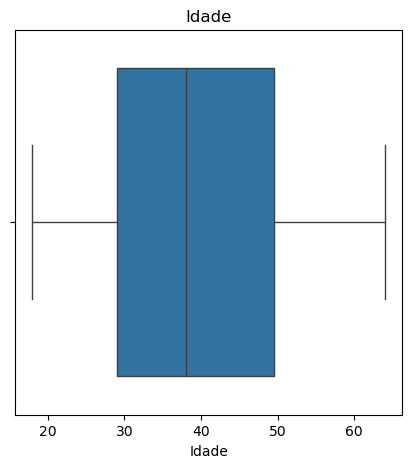

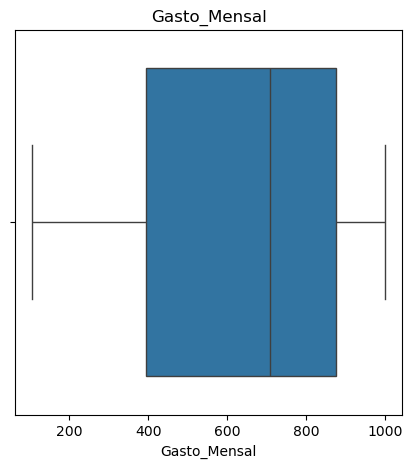

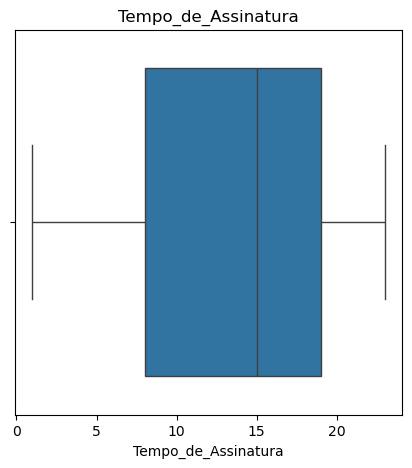

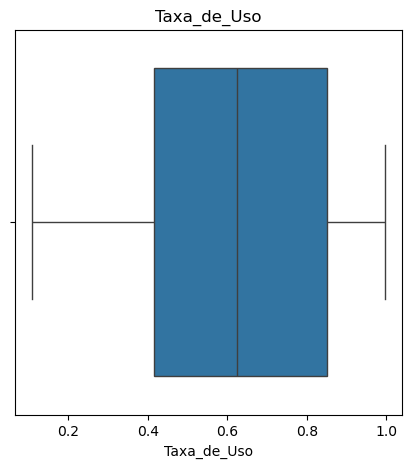

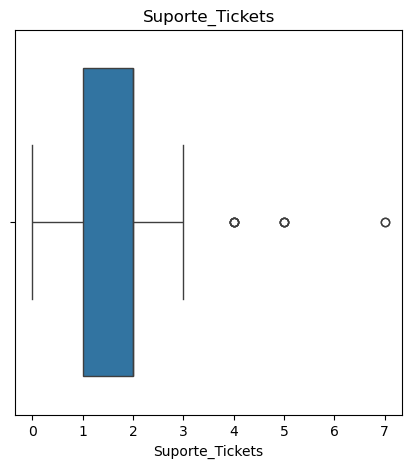

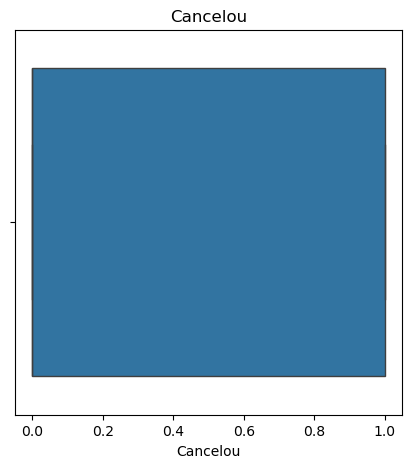

In [7]:
for colunm in df.columns:
    if df[colunm].dtype in ['int64', 'float64']:
        plt.figure(figsize= (5,5))
        sns.boxplot(x = df[colunm])
        plt.title(colunm)
        plt.show()

## Verificação inicial dos dados

A variável `Suporte_Tickets` apresentou valores potencialmente extremos segundo o critério do intervalo interquartil (IQR). Já a variável `Cancelou`, embora representada numericamente por `0` e `1`, possui natureza categórica binária:

- `0`: cliente não cancelou;
- `1`: cliente cancelou.

Os possíveis outliers serão avaliados posteriormente para verificar se representam erros ou comportamentos reais e relevantes para o negócio.

In [8]:
print(df['Cancelou'].value_counts())
df.describe()

Cancelou
0    50
1    49
Name: count, dtype: int64


,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,39.888889,639.071009,13.646465,0.604374,1.747475,0.494949
std,13.089869,270.618268,6.599804,0.263824,1.486974,0.502519
min,18.000000,106.254563,1.000000,0.110168,0.000000,0.000000
25%,29.000000,394.918421,8.000000,0.414928,1.000000,0.000000
50%,38.000000,709.104722,15.000000,0.623406,2.000000,0.000000
75%,49.500000,875.735422,19.000000,0.849839,2.000000,1.000000
max,64.000000,999.943535,23.000000,0.996007,7.000000,1.000000


In [9]:
# Seleciona somente as colunas numéricas
colunas_numericas = df.select_dtypes(include="number").columns

# Cálculo dos quartis
q1 = df[colunas_numericas].quantile(0.25)
q3 = df[colunas_numericas].quantile(0.75)

# Intervalo interquartil
iqr = q3 - q1

# Limites para cada coluna
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Verifica os outliers em cada célula
outliers = (
    (df[colunas_numericas] < limite_inferior)
    | (df[colunas_numericas] > limite_superior)
).any(axis=1)

df_outlier = df[outliers]

In [10]:
df_outlier

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou
12,46,743.034018,16,0.697133,5,0
52,41,595.076602,14,0.512320,4,1
53,48,550.847824,12,0.619646,7,1
54,43,667.040379,13,0.630056,5,0
63,34,694.989179,17,0.536049,7,1
79,59,805.273395,21,0.887495,4,1
80,45,875.292673,23,0.980832,4,1
87,52,968.423785,19,0.989904,4,1
89,56,893.738632,23,0.985318,4,1
95,53,999.943535,23,0.865750,5,1


In [11]:
# Matriz de Correlação

correlation_matrix = df.corr()
correlation_matrix

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou
Idade,1.000000,0.856041,0.814066,0.846363,0.431047,0.624298
Gasto_Mensal,0.856041,1.000000,0.914275,0.912730,0.378802,0.651229
Tempo_de_Assinatura,0.814066,0.914275,1.000000,0.891799,0.427516,0.687107
Taxa_de_Uso,0.846363,0.912730,0.891799,1.000000,0.380526,0.643879
Suporte_Tickets,0.431047,0.378802,0.427516,0.380526,1.000000,0.278220
Cancelou,0.624298,0.651229,0.687107,0.643879,0.278220,1.000000


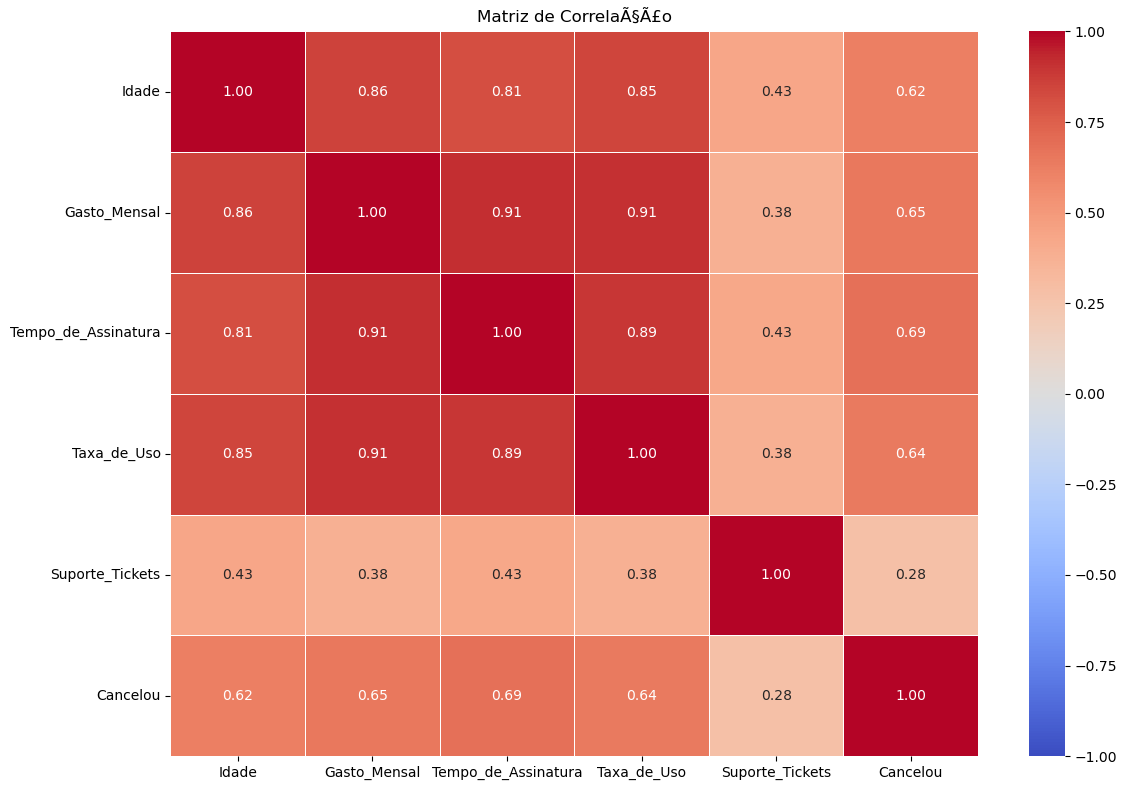

In [12]:
# Tamanho do gráfico
plt.figure(figsize=(12, 8))

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

## Padronização das variáveis

Como as variáveis possuem escalas diferentes, por exemplo, `Gasto_Mensal` apresenta valores muito superiores aos de `Suporte_Tickets`, foi aplicado o `StandardScaler`.

A padronização transforma as variáveis para média próxima de zero e desvio-padrão próximo de um, impedindo que atributos de maior escala dominem o cálculo das distâncias do K-Means. Esse procedimento não elimina multicolinearidade nem reduz a dimensionalidade; ele apenas torna as variáveis comparáveis no processo de clusterização.

In [13]:
# Padronizador

scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df), columns= df.columns)

In [14]:
df_scaled.sample(6)

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou
78,1.390639,0.631287,1.272166,1.044144,0.170689,1.010153
37,-1.373576,-0.568134,-1.164486,-1.637201,-1.181169,-0.989949
65,0.238883,0.370167,0.206131,-0.292714,0.170689,1.010153
54,0.238883,0.103880,-0.098451,0.097843,2.198477,-0.989949
15,-0.912873,-0.764325,-1.925940,-1.169026,-1.181169,-0.989949
20,-1.450360,-1.370516,-0.403032,-1.873617,-1.181169,1.010153


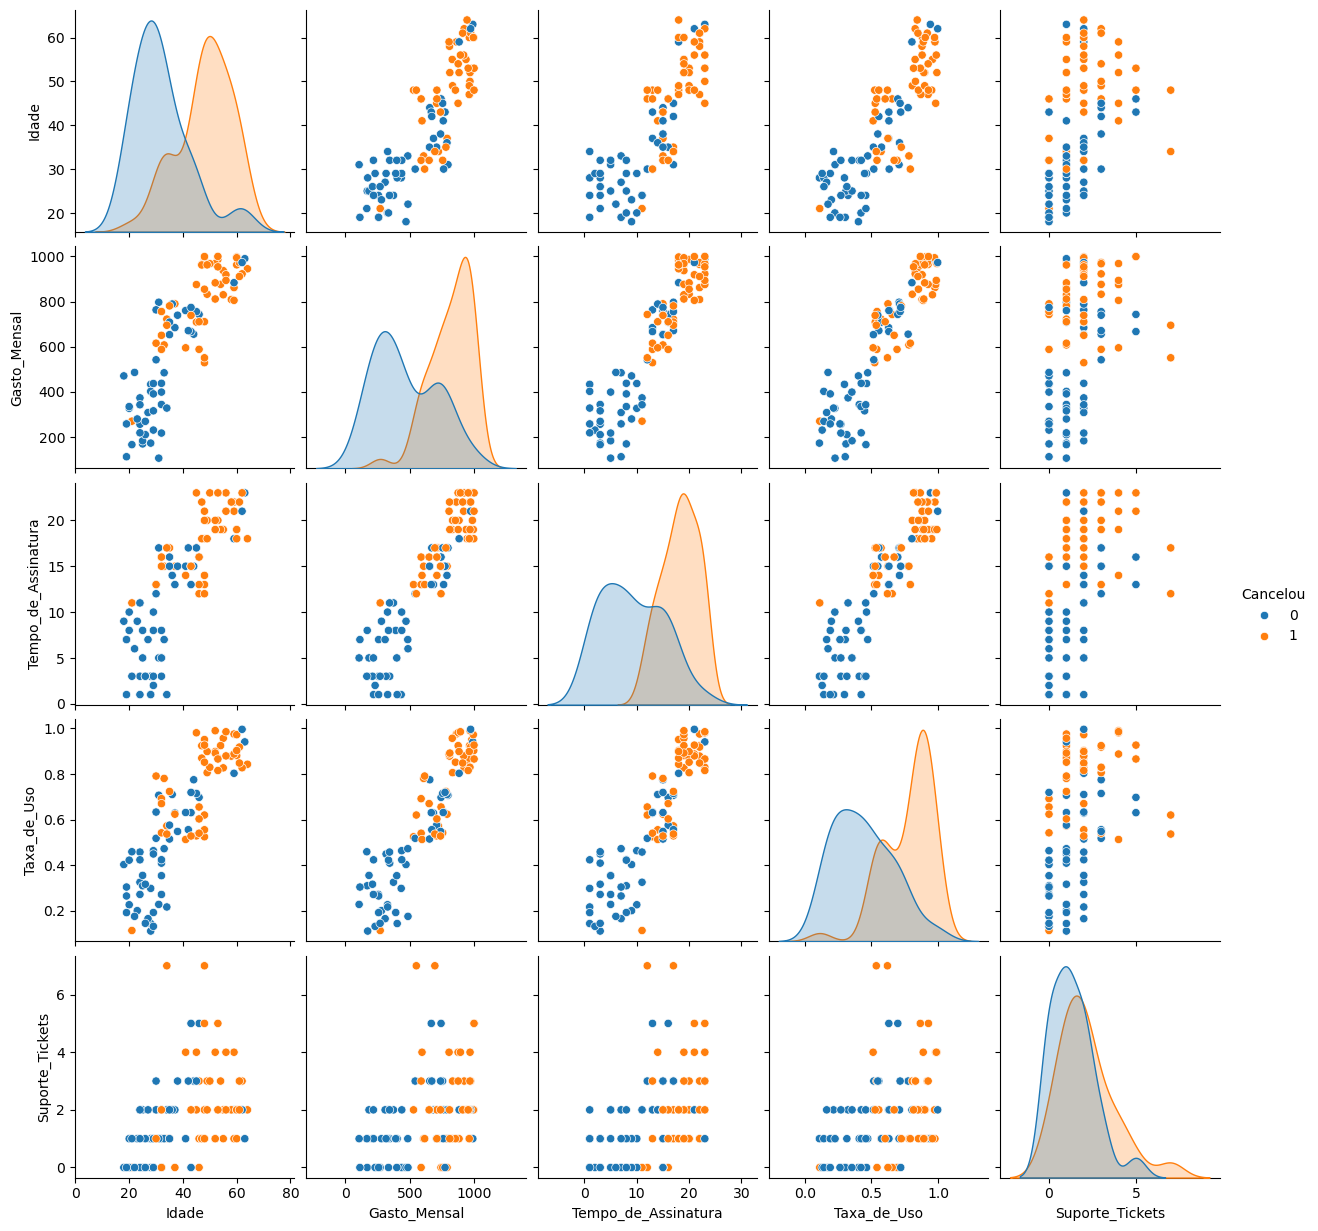

In [15]:
# Visualizando relação de Cancelou com as demais variáveis
sns.pairplot(df,hue = 'Cancelou', diag_kind= 'kde')
plt.show()

# Clusterização com outliers

In [16]:
# Lista para armazenar o SEE

sse = []
k_range = range(1,11)

In [17]:
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_)

  File "c:\Users\Brener\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Brener\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Brener\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Brener\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


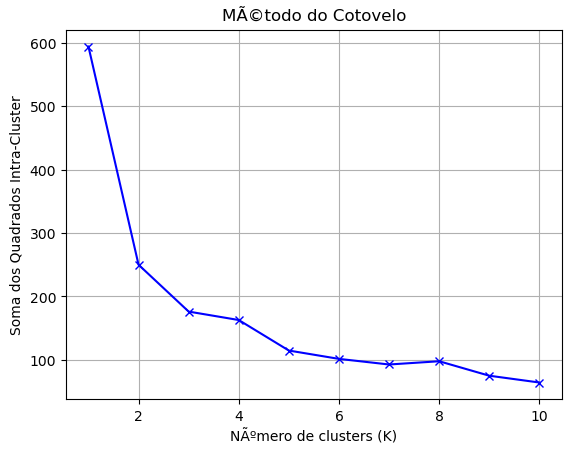

In [18]:

# Gráfico do cotovelo

plt.plot(
    k_range,
    sse,
    'bx-'
)

plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Soma dos Quadrados Intra-Cluster")
plt.title('Método do Cotovelo')
plt.grid(True)
plt.show()

# Método da silhueta

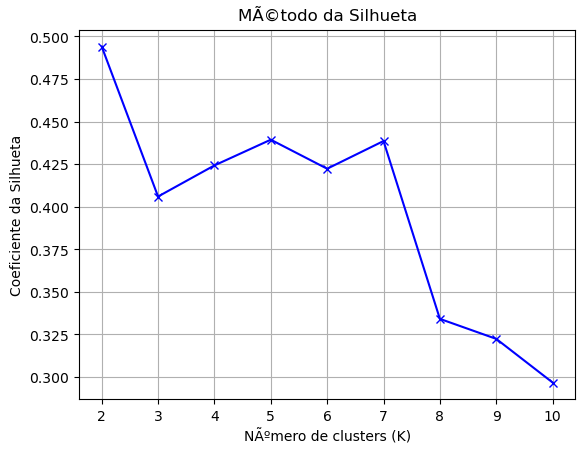

In [19]:
sil_score = []
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_scaled)

    if k != 1:
        sil_score.append(silhouette_score(df_scaled, kmeans.labels_))



# Gráfico do cotovelo

plt.plot(
    k_range[1:],
    sil_score,
    'bx-'
)

plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente da Silhueta")
plt.title('Método da Silhueta')
plt.grid(True)
plt.show()

Os métodos do cotovelo e da silhueta indicaram que quatro clusters poderiam ser uma solução inicial adequada. Por isso, foi construída uma primeira versão do modelo com `K = 4`, cuja separação será avaliada visualmente antes da definição do número final de grupos.

# Construção da primeira versão do modelo

In [20]:
# Modelo com 4 clusters

modelo_kmeans_v1 = KMeans(n_clusters=4, random_state=42)

df['cluster']= modelo_kmeans_v1.fit_predict(df_scaled)

In [21]:
df.sample(6)

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou,cluster
61,32,650.454888,16,0.669811,2,1,2
92,52,811.275099,19,0.891827,1,1,1
97,61,911.086341,22,0.848029,2,1,1
91,48,854.681414,20,0.851649,1,1,1
41,21,166.106776,3,0.458437,1,0,0
83,55,830.083378,19,0.956731,1,1,1


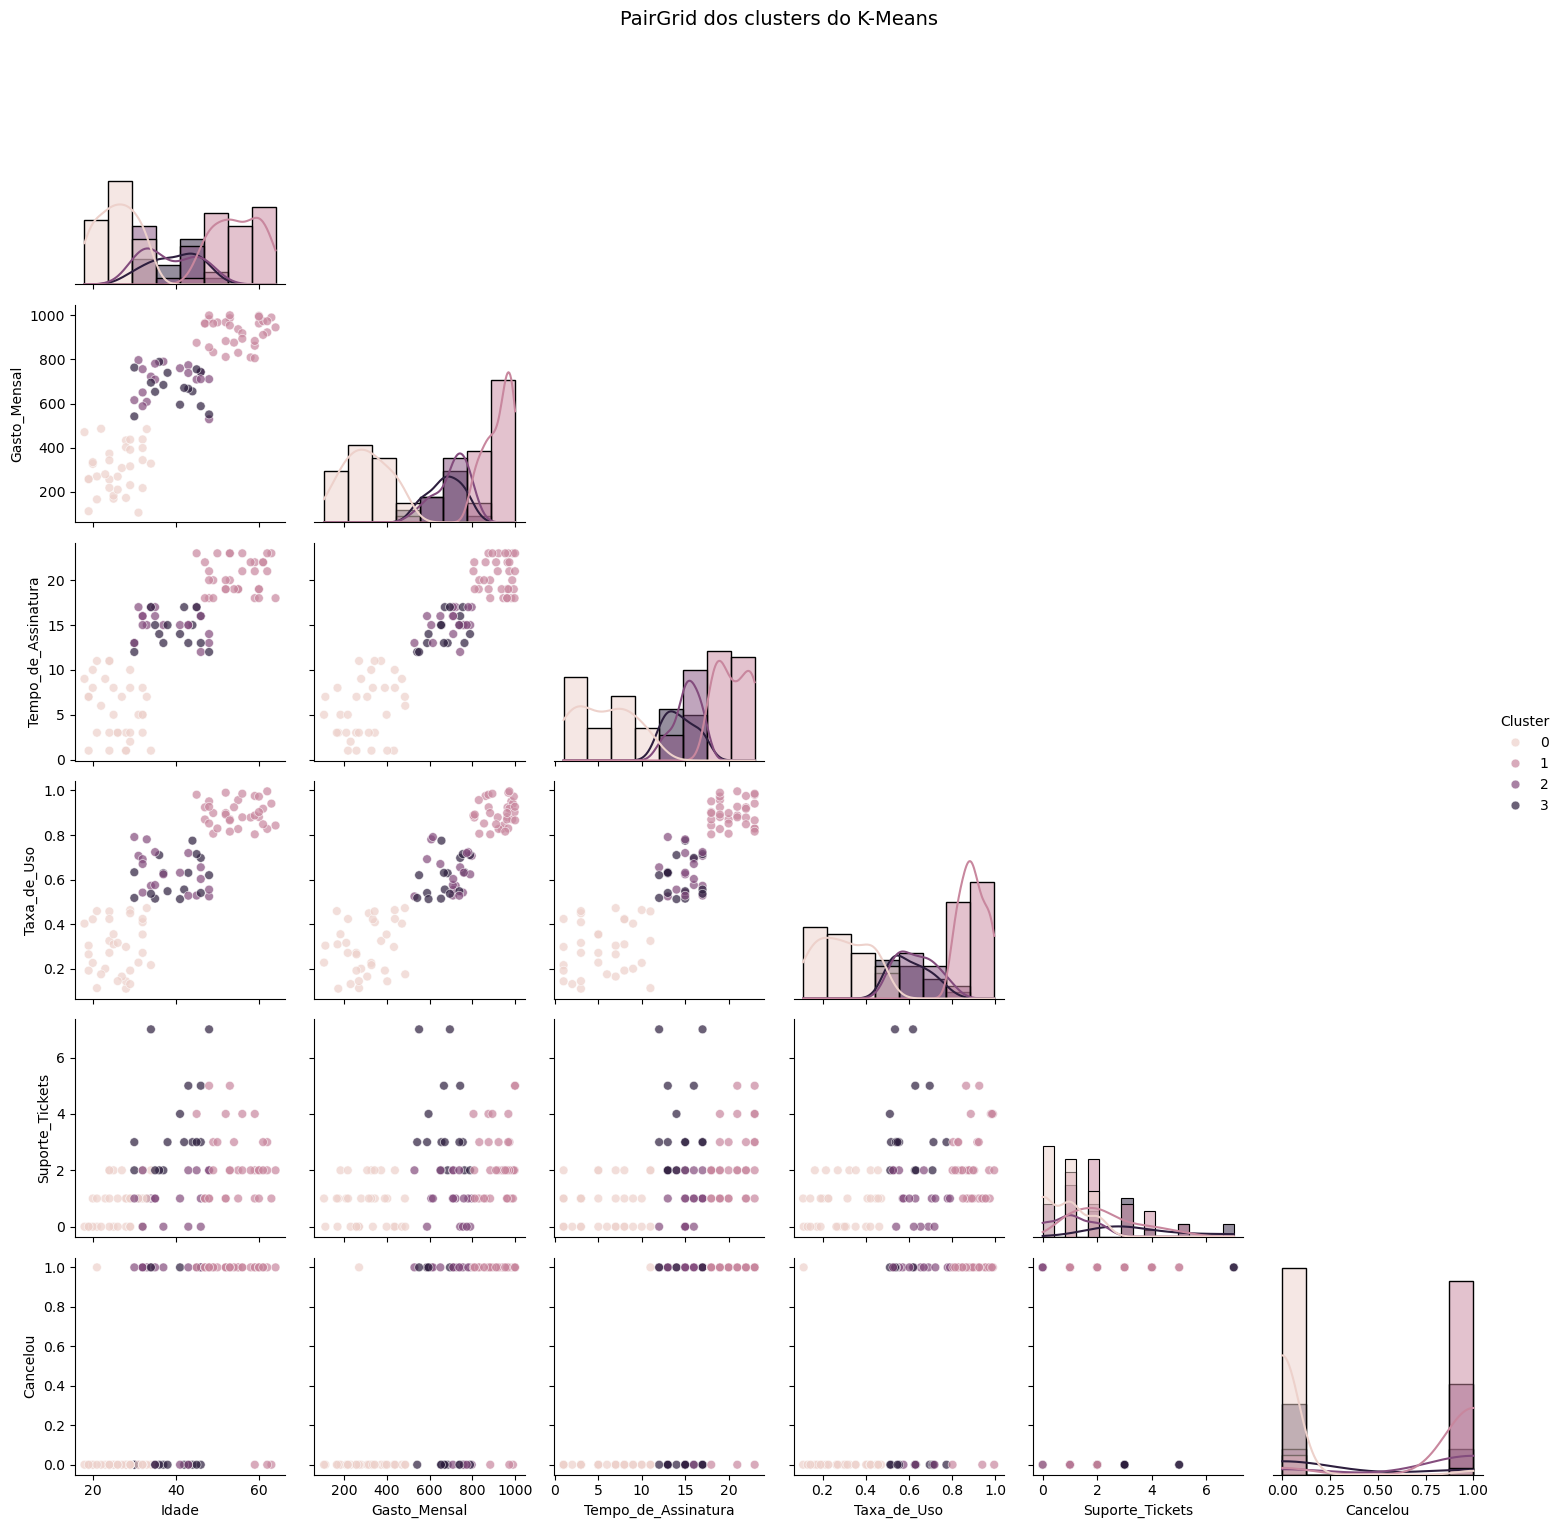

In [22]:
# Criar o PairGrid
grid = sns.PairGrid(
    df,
    vars=colunas_numericas,
    hue='cluster',
    corner=True,
    height=2.5
)

# Gráficos fora da diagonal
grid.map_lower(
    sns.scatterplot,
    alpha=0.7,
    s=40
)

# Distribuições na diagonal
grid.map_diag(
    sns.histplot,
    kde=True,
    alpha=0.5
)

grid.add_legend(title='Cluster')

plt.suptitle(
    'PairGrid dos clusters do K-Means',
    y=1.02,
    fontsize=14
)

plt.show()

A inspeção do PairGrid indica que os clusters 2 e 3 apresentam perfis bastante semelhantes e sobreposição relevante em diferentes combinações de variáveis. Essa proximidade sugere que a solução com quatro grupos pode estar fragmentando um mesmo perfil de clientes em dois clusters pouco distintos.

Diante disso, será testada uma nova versão com três clusters, buscando uma segmentação mais simples, interpretável e útil para o negócio.

In [23]:
# Modelo com 3 clusters

modelo_kmeans_v2 = KMeans(n_clusters=3, random_state=42)

In [24]:
df.drop('cluster',axis=1, inplace=True)

In [25]:
df['cluster'] =modelo_kmeans_v2.fit_predict(df_scaled)

In [26]:
df.sample(6)

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou,cluster
19,28,402.144564,1,0.143157,1,0,0
6,34,722.230585,17,0.571936,1,1,2
79,59,805.273395,21,0.887495,4,1,1
75,59,883.648607,18,0.802909,2,0,1
23,19,112.525317,7,0.303428,0,0,0
40,24,218.509402,1,0.422976,1,0,0


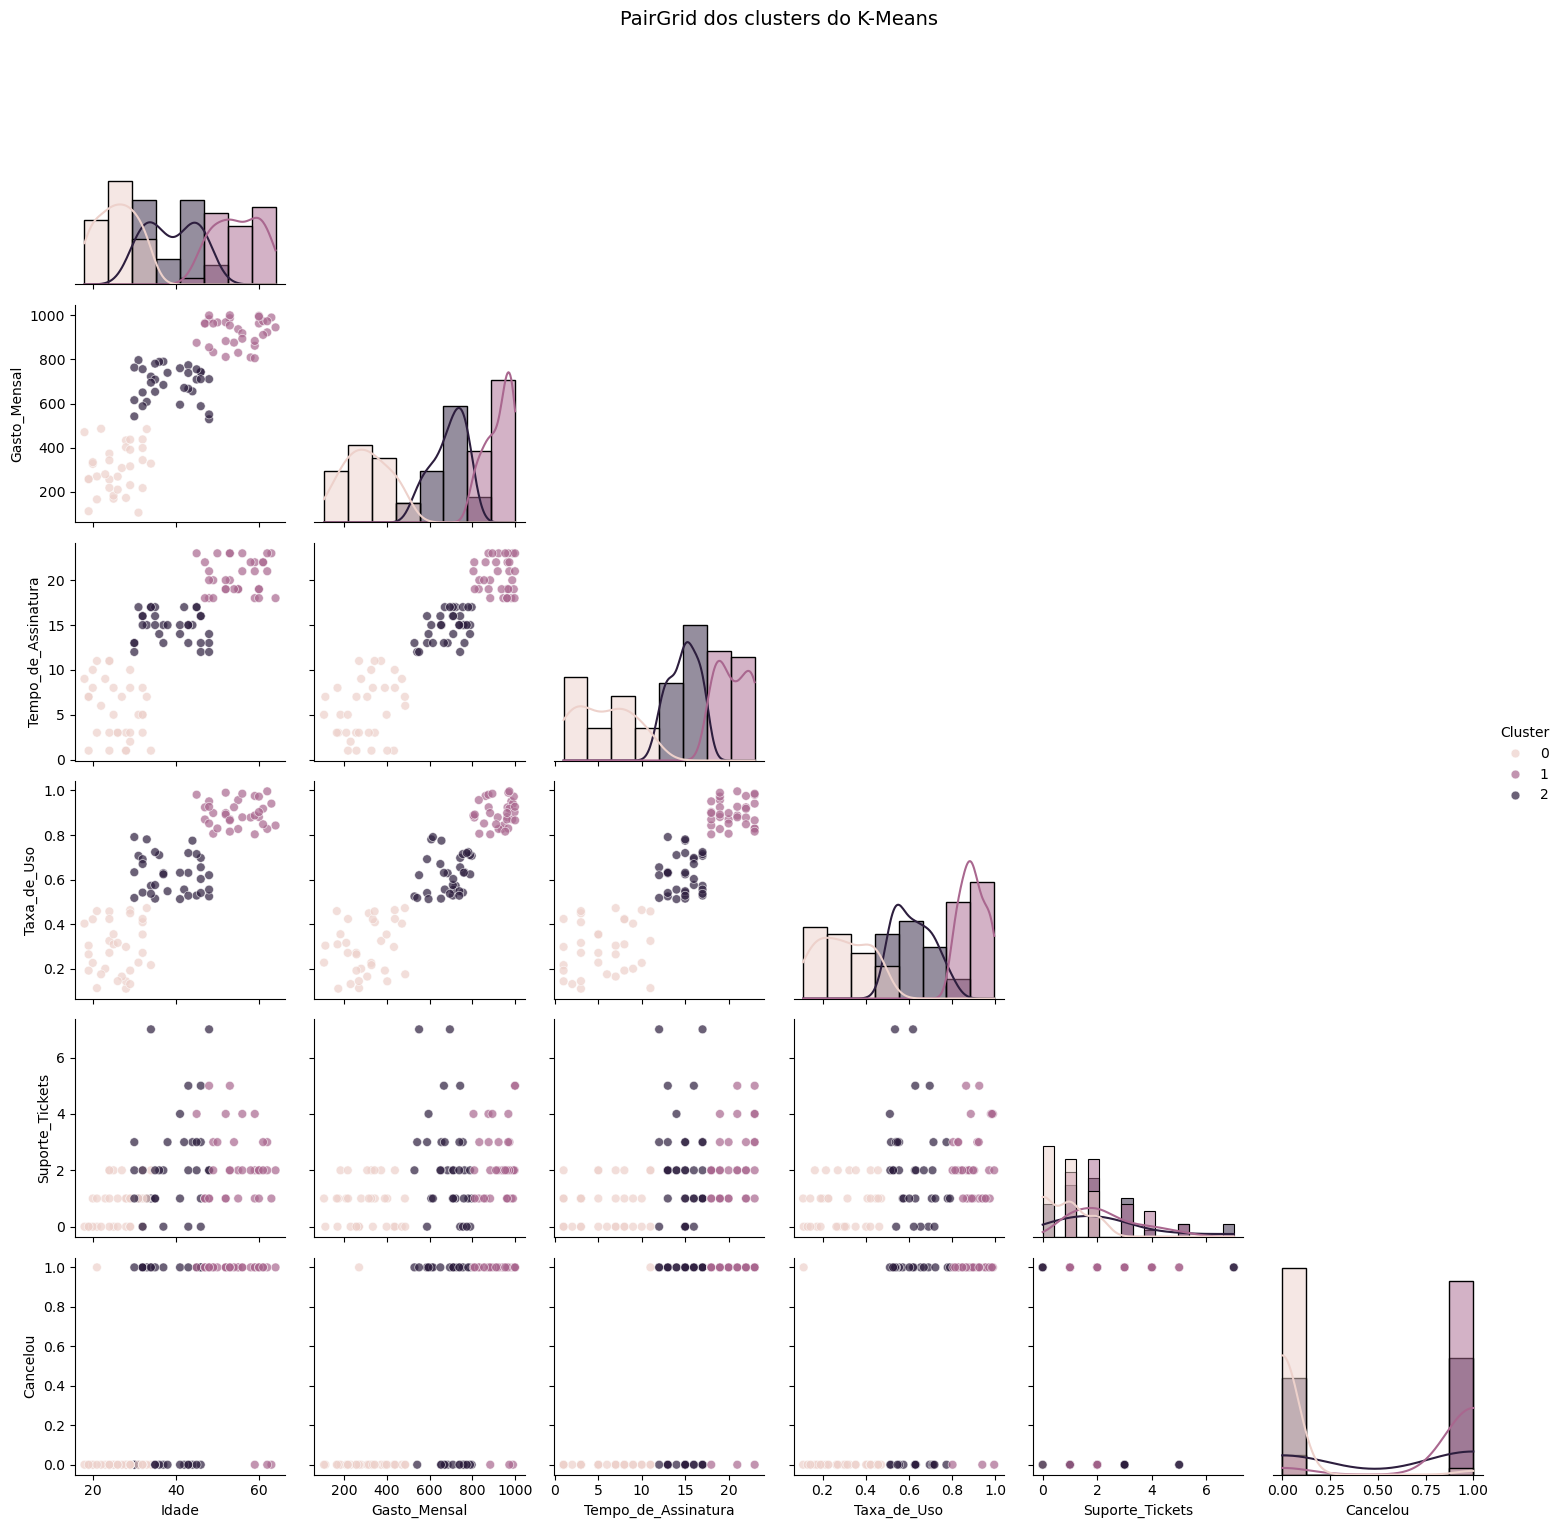

In [27]:
# Criar o PairGrid
grid = sns.PairGrid(
    df,
    vars=colunas_numericas,
    hue='cluster',
    corner=True,
    height=2.5
)

# Gráficos fora da diagonal
grid.map_lower(
    sns.scatterplot,
    alpha=0.7,
    s=40
)

# Distribuições na diagonal
grid.map_diag(
    sns.histplot,
    kde=True,
    alpha=0.5
)

grid.add_legend(title='Cluster')

plt.suptitle(
    'PairGrid dos clusters do K-Means',
    y=1.02,
    fontsize=14
)

plt.show()

A solução com três clusters apresentou uma separação visual mais clara e perfis mais distintos entre si. Por esse motivo, o modelo com `K = 3` foi selecionado como versão final para a interpretação dos grupos.

Em seguida, será verificado se os valores extremos de `Suporte_Tickets` alteram de forma relevante a estrutura dessa segmentação.

# Clusterização sem outliers

In [28]:
df_cleaned = df[~outliers]

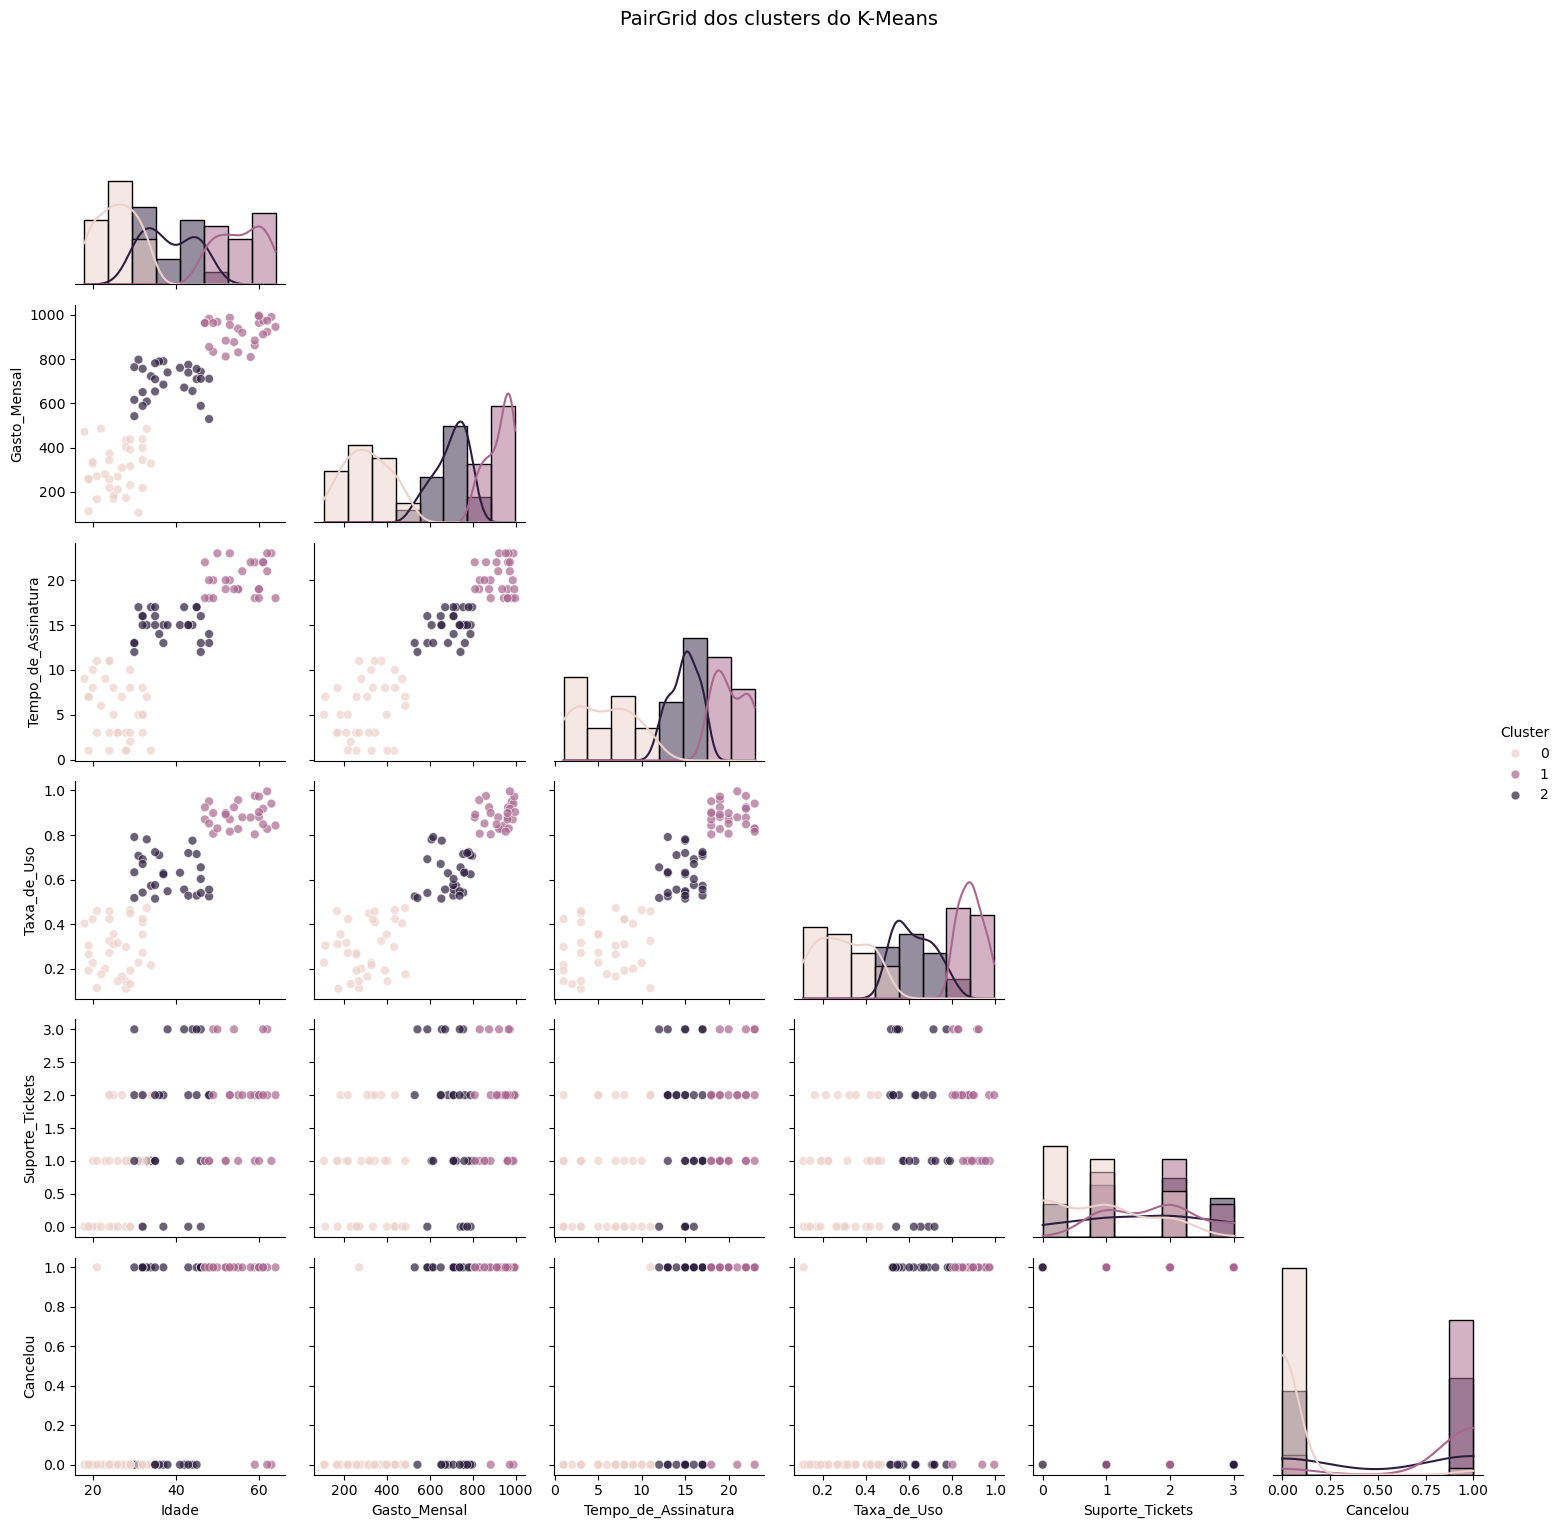

In [29]:
# Criar o PairGrid
grid = sns.PairGrid(
    df_cleaned,
    vars=colunas_numericas,
    hue='cluster',
    corner=True,
    height=2.5
)

# Gráficos fora da diagonal
grid.map_lower(
    sns.scatterplot,
    alpha=0.7,
    s=40
)

# Distribuições na diagonal
grid.map_diag(
    sns.histplot,
    kde=True,
    alpha=0.5
)

grid.add_legend(title='Cluster')

plt.suptitle(
    'PairGrid dos clusters do K-Means',
    y=1.02,
    fontsize=14
)

plt.show()

# Comparação do modelo com e sem outliers

In [30]:
# Dados padronizados originalmente, retirando apenas as linhas outliers
df_scaled_cleaned = df_scaled.loc[df_cleaned.index].copy()

In [31]:
# Novo K-Means treinado somente com as observações sem outliers
modelo_kmeans_sem_outliers = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_sem_outliers = modelo_kmeans_sem_outliers.fit_predict(
    df_scaled_cleaned
)

In [32]:
df_cleaned_comparacao = df_cleaned.copy()

# Cluster antigo: calculado pelo modelo treinado com outliers
df_cleaned_comparacao['cluster_com_outliers'] = df_cleaned['cluster']

# Cluster novo: calculado pelo modelo treinado sem outliers
df_cleaned_comparacao['cluster_sem_outliers'] = clusters_sem_outliers

In [33]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

metricas_com_outliers = {
    'Silhouette': silhouette_score(
        df_scaled_cleaned,
        df_cleaned_comparacao['cluster_com_outliers']
    ),

    'Davies-Bouldin': davies_bouldin_score(
        df_scaled_cleaned,
        df_cleaned_comparacao['cluster_com_outliers']
    ),

    'Calinski-Harabasz': calinski_harabasz_score(
        df_scaled_cleaned,
        df_cleaned_comparacao['cluster_com_outliers']
    )
}

metricas_sem_outliers = {
    'Silhouette': silhouette_score(
        df_scaled_cleaned,
        df_cleaned_comparacao['cluster_sem_outliers']
    ),

    'Davies-Bouldin': davies_bouldin_score(
        df_scaled_cleaned,
        df_cleaned_comparacao['cluster_sem_outliers']
    ),

    'Calinski-Harabasz': calinski_harabasz_score(
        df_scaled_cleaned,
        df_cleaned_comparacao['cluster_sem_outliers']
    )
}

comparacao_metricas = pd.DataFrame({
    'Modelo treinado com outliers': metricas_com_outliers,
    'Modelo treinado sem outliers': metricas_sem_outliers
})

comparacao_metricas.round(4)

,Modelo treinado com outliers,Modelo treinado sem outliers
Silhouette,0.4494,0.4494
Davies-Bouldin,0.9842,0.9842
Calinski-Harabasz,133.8466,133.8466


In [34]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    df_cleaned_comparacao['cluster_com_outliers'],
    df_cleaned_comparacao['cluster_sem_outliers']
)

print(f'Adjusted Rand Index: {ari:.6f}')

Adjusted Rand Index: 1.000000


As métricas de avaliação foram idênticas nos modelos treinados com e sem os registros considerados outliers. Além disso, o Adjusted Rand Index foi igual a `1`, indicando correspondência total entre os agrupamentos formados para as observações não extremas.

Portanto, a retirada desses registros não modificou a estrutura dos clusters. O principal efeito dos valores extremos ocorreu na amplitude e na visualização dos gráficos, e não na composição dos grupos.

## Decisão sobre os outliers

Os clientes com maior quantidade de tickets de suporte foram mantidos no conjunto de dados. Os valores observados, chegando a sete chamados, são plausíveis no contexto do negócio e representam clientes que recorreram ao suporte com maior frequência, não erros de registro.

Além de não alterarem a estrutura dos clusters, esses casos são relevantes para compreender possíveis sinais de insatisfação e cancelamento. Assim, o modelo final utilizado na interpretação dos grupos é o modelo de três clusters treinado com todos os registros.

In [35]:
centroides  = modelo_kmeans_v2.cluster_centers_

In [36]:
print(centroides)

[[-1.07807472 -1.24869086 -1.22447918 -1.1858289  -0.64861907 -0.92934034]
 [ 1.14865372  1.05786786  1.04142262  1.11634458  0.35503359  0.82832509]
 [-0.07057899  0.19082299  0.18305656  0.06948432  0.29358547  0.10101525]]


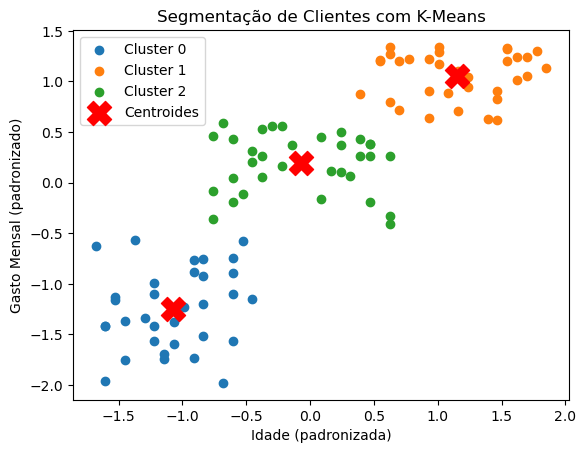

In [50]:
# Plotar os pontos de cada cluster
for cluster_num in range(3):

    mask = df['cluster'] == cluster_num

    plt.scatter(
        df_scaled.loc[mask].iloc[:, 0],
        df_scaled.loc[mask].iloc[:, 1],
        label=f'Cluster {cluster_num}'
    )

# Plotar os centróides
plt.scatter(
    modelo_kmeans_v2.cluster_centers_[:, 0],
    modelo_kmeans_v2.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centróides'
)

plt.legend()
plt.title('Segmentação de Clientes com K-Means')
plt.xlabel('Idade (padronizada)')
plt.ylabel('Gasto Mensal (padronizado)')
# Salvar em PNG
plt.savefig("segmentacao_clientes.png", dpi=300)
plt.show()



In [38]:
df[df.cluster == 0].head(5)

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou,cluster
13,24,373.305408,11,0.324511,2,0,0
14,32,343.998663,3,0.408387,1,0,0
15,28,433.277965,1,0.297518,0,0,0
16,25,169.345861,8,0.309093,0,0,0
17,24,256.424243,3,0.271016,0,0,0


In [39]:
df[df.cluster == 0].mean()

Idade                   25.848485
Gasto_Mensal           302.863443
Tempo_de_Assinatura      5.606061
Taxa_de_Uso              0.293108
Suporte_Tickets          0.787879
Cancelou                 0.030303
cluster                  0.000000
dtype: float64

In [40]:
df[df.cluster == 1].head(5)

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou,cluster
66,59,861.905523,22,0.975331,1,1,1
67,60,962.759004,19,0.880697,1,1,1
68,55,936.946235,19,0.826803,2,1,1
69,49,832.523388,20,0.805757,3,1,1
70,48,982.185437,18,0.951027,1,1,1


In [41]:
df[df.cluster == 1].mean()

Idade                   54.848485
Gasto_Mensal           923.899857
Tempo_de_Assinatura     20.484848
Taxa_de_Uso              0.897401
Suporte_Tickets          2.272727
Cancelou                 0.909091
cluster                  1.000000
dtype: float64

In [42]:
df[df.cluster == 2].head(5)

,Idade,Gasto_Mensal,Tempo_de_Assinatura,Taxa_de_Uso,Suporte_Tickets,Cancelou,cluster
0,48,529.152948,13,0.524262,2,1,2
1,37,684.502168,13,0.628494,2,0,2
2,31,797.016155,17,0.706550,1,0,2
3,30,542.025205,12,0.517458,3,0,2
4,44,655.498896,15,0.774564,3,0,2


In [43]:
df[df.cluster == 2].mean()

Idade                   38.969697
Gasto_Mensal           690.449726
Tempo_de_Assinatura     14.848485
Taxa_de_Uso              0.622612
Suporte_Tickets          2.181818
Cancelou                 0.545455
cluster                  2.000000
dtype: float64

# Interpretação final dos clusters

A tabela abaixo resume o perfil médio dos três grupos considerando todos os clientes, inclusive os registros com maior número de tickets de suporte.

In [44]:
perfil_clusters = df.groupby('cluster').agg(
    Quantidade_Clientes=('Cancelou', 'size'),
    Idade_Media=('Idade', 'mean'),
    Gasto_Mensal_Medio=('Gasto_Mensal', 'mean'),
    Tempo_Medio_Assinatura=('Tempo_de_Assinatura', 'mean'),
    Taxa_Media_Uso=('Taxa_de_Uso', 'mean'),
    Media_Tickets_Suporte=('Suporte_Tickets', 'mean'),
    Taxa_Cancelamento=('Cancelou', 'mean')
)

perfil_clusters['Taxa_Cancelamento'] = perfil_clusters['Taxa_Cancelamento'] * 100
perfil_clusters.round(2)


,Quantidade_Clientes,Idade_Media,Gasto_Mensal_Medio,Tempo_Medio_Assinatura,Taxa_Media_Uso,Media_Tickets_Suporte,Taxa_Cancelamento
cluster,,,,,,,
0,33,25.85,302.86,5.61,0.29,0.79,3.03
1,33,54.85,923.90,20.48,0.90,2.27,90.91
2,33,38.97,690.45,14.85,0.62,2.18,54.55


## Cluster 0 - Clientes novos, de baixo consumo e majoritariamente retidos

O Cluster 0 reúne 33 clientes com o perfil mais jovem da base, idade média de aproximadamente 26 anos. Eles apresentam o menor gasto mensal médio, cerca de R$ 302,86, pouco tempo de assinatura, aproximadamente 5,6 meses, baixa taxa de uso e menos de um ticket de suporte por cliente.

A taxa de cancelamento do grupo é de apenas 3,03%, equivalente a um cliente entre os 33 integrantes. Portanto, este cluster representa clientes ainda no início do relacionamento com a empresa, com baixo consumo e baixa interação, mas que permanecem majoritariamente ativos.

**Estratégia recomendada:** campanhas de ativação, estímulo ao uso, apresentação de funcionalidades, ofertas de upgrade e ações de relacionamento que aumentem o valor percebido antes que esses clientes percam o interesse.

## Cluster 1 - Clientes maduros, de alto valor e com cancelamento crítico

O Cluster 1 também possui 33 clientes e concentra o perfil de maior valor financeiro e maior intensidade de uso. A idade média é de aproximadamente 55 anos, o gasto mensal médio chega a R$ 923,90, o tempo médio de assinatura supera 20 meses e a taxa média de uso é a mais elevada entre os grupos.

Apesar desse alto envolvimento, a taxa de cancelamento alcança 90,91%, correspondente a 30 dos 33 clientes. O grupo também apresenta a maior média de tickets de suporte, cerca de 2,27 chamados por cliente. Isso indica que clientes importantes e antigos podem estar enfrentando problemas de experiência, atendimento, preço ou desgaste do relacionamento.

**Estratégia recomendada:** priorizar ações de recuperação e prevenção de churn, investigar os motivos dos chamados, realizar contato personalizado, oferecer atendimento prioritário, benefícios de fidelização e campanhas de reconquista para clientes já cancelados.

## Cluster 2 - Clientes intermediários com risco elevado de cancelamento

O Cluster 2 é formado por 33 clientes com características intermediárias. A idade média é de aproximadamente 39 anos, o gasto mensal médio é de R$ 690,45, o tempo médio de assinatura é de 14,85 meses e a taxa média de uso é de 0,62. A média de tickets de suporte, 2,18, aproxima-se da observada no grupo de maior cancelamento.

A taxa de cancelamento é de 54,55%, equivalente a 18 dos 33 clientes. Esse resultado revela um grupo dividido entre clientes ativos e cancelados e, por isso, representa o principal segmento de atenção preventiva. Os clientes ainda ativos desse cluster compartilham características com outros que já deixaram a empresa.

**Estratégia recomendada:** direcionar campanhas preventivas de retenção, acompanhar a frequência de chamados, oferecer suporte proativo, benefícios personalizados e incentivos de permanência antes que o comportamento evolua para o cancelamento.

# Conclusão de negócio

A segmentação revelou três estágios distintos da relação dos clientes com a empresa:

- o **Cluster 0** representa clientes novos e retidos, que precisam ser estimulados a aumentar o uso e o relacionamento;
- o **Cluster 1** concentra clientes de alto valor que já cancelaram em grande proporção, exigindo investigação das causas e estratégias de recuperação;
- o **Cluster 2** reúne clientes em situação intermediária e com elevada incidência de cancelamento, sendo o principal público para ações preventivas.

Os resultados permitem que a empresa abandone campanhas genéricas e adote estratégias específicas para ativação, retenção e reconquista. A clusterização descreve os perfis presentes neste conjunto de dados e oferece apoio à tomada de decisão, mas não deve ser interpretada isoladamente como uma previsão causal ou individual de cancelamento.